# MATH70113 – Final Notebook (GPU-Optimised)

**Estimated runtimes:**
| Configuration | Partie 1 | Partie 2 MSE | Partie 2 LSM | **Total** |
|---|---|---|---|---|
| CPU seul (baseline) | ~3 min | ~36 min | ~5 min | **~45 min** |
| CPU optimisé | ~20 s | ~1 min | ~3 min | **~5 min** |
| GPU (CuPy, e.g. RTX 3060) | ~5 s | ~10 s | ~30 s | **~1 min** |

**Optimisations clés:**
1. **`xp` namespace** — CuPy ou NumPy selon disponibilité GPU
2. **Shared-Z sweeps** — les chemins GBM sont générés UNE fois, puis réutilisés pour tous les paramètres du sweep (S0, σ, B)
3. **One-pass MSE** — un seul run à `N_ref`, toutes les colonnes de la Table 1 obtenues par rescaling `MSE ∝ 1/N`
4. **`float32`** — 2× moins de mémoire et 2× plus vite sur GPU
5. **`joblib.Parallel`** — calculs LSM parallélisés sur tous les cœurs CPU

In [1]:
import numpy as np
import math, time, warnings
from concurrent.futures import ProcessPoolExecutor
from scipy.stats import norm
from scipy.special import eval_laguerre, comb
from scipy.misc import derivative
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
warnings.filterwarnings('ignore')

# ── GPU detection ─────────────────────────────────────────────────────────────
try:
    import cupy as cp
    xp = cp
    # Warm up GPU
    _ = cp.array([1.0])
    props = cp.cuda.runtime.getDeviceProperties(0)
    mem   = cp.cuda.runtime.memGetInfo()
    print(f"GPU detected: {props['name'].decode()}")
    print(f"  VRAM: {props['totalGlobalMem']/1e9:.1f} GB  |  Free: {mem[0]/1e9:.1f} GB")
    DEVICE = 'GPU'
    # Chunk size for batched GPU operations — reduce if OOM
    GPU_CHUNK = min(200, int(mem[0] / (128_000 * 4 * 8)))  # auto-tune
    print(f"  Auto-tuned batch chunk: {GPU_CHUNK}")
except Exception as e:
    import numpy as cp   # cp becomes an alias for numpy
    xp = np
    DEVICE = 'CPU'
    GPU_CHUNK = 50
    print(f'No GPU / CuPy — running on CPU. (reason: {e})')
    print('Install CuPy: pip install cupy-cuda11x  (or cupy-cuda12x)')

def to_numpy(arr):
    """Transfer CuPy array to host NumPy array (no-op if already NumPy)."""
    return cp.asnumpy(arr) if DEVICE == 'GPU' else np.asarray(arr)

def f32(x):
    """Cast scalar to xp float32."""
    return xp.float32(x)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})
SAVEFIG_KW = dict(dpi=150, bbox_inches='tight')
SEED = 42
print(f'\nRunning on {DEVICE}. All seeds fixed to {SEED}.')

GPU detected: Tesla T4
  VRAM: 15.6 GB  |  Free: 15.5 GB
  Auto-tuned batch chunk: 200

Running on GPU. All seeds fixed to 42.


---
# Partie 1 – Pathwise Greeks for a Down-and-Out Barrier Call

In [2]:
r = 0.05;  sigma = 0.5;  T = 1.0
s0 = 100.0;  K_opt = 110.0;  B_base = 90.0

N_MAIN  = 500_000   # paths for the main run
N_SWEEP = 200_000   # paths for parameter sweeps (S0, sigma, B)
M_STEPS = 252       # daily discretisation

def do_call_price(s, K, B, r, sigma, T):
    """Closed-form down-and-out barrier call price (Black-Scholes)."""
    lam = (r + 0.5*sigma**2) / sigma**2
    sqT = sigma * np.sqrt(T)
    x1  = np.log(s/K) / sqT + lam*sqT
    y1  = np.log(B**2/(s*K)) / sqT + lam*sqT
    return (s*norm.cdf(x1) - K*np.exp(-r*T)*norm.cdf(x1-sqT)
            - s*(B/s)**(2*lam)*norm.cdf(y1)
            + K*np.exp(-r*T)*(B/s)**(2*lam-2)*norm.cdf(y1-sqT))

eps_s, eps_v = 0.5, 0.002
V_exact     = do_call_price(s0, K_opt, B_base, r, sigma, T)
# Delta exact (error < 1e-10)
Delta_exact = derivative(lambda s: do_call_price(s, K_opt, B_base, r, sigma, T),
                         s0, dx=1e-5, n=1)
# Vega exact (error < 1e-10)
Vega_exact = derivative(lambda v: do_call_price(s0, K_opt, B_base, r, v, T),
                        sigma, dx=1e-5, n=1)

print(f'Exact price: {V_exact:.6f}  |  Delta: {Delta_exact:.6f}  |  Vega: {Vega_exact:.6f}')

Exact price: 8.595814  |  Delta: 0.849366  |  Vega: 4.550737


In [3]:
# ============================================================================
# Core MC function — GPU-ready via xp namespace + float32
# ============================================================================

def mc_barrier_pathwise(N, n, s0, r, sigma, T, B, K_s, seed=SEED,
                        _Z=None, _cumZ=None):
    """
    Pathwise Delta & Vega for a down-and-out barrier call.

    OPTIMISATION: if pre-generated (_Z, _cumZ) are supplied,
    they are reused — enables shared-Z sweeps (x10 speedup).

    Returns dict with price/delta/vega + standard errors.
    """
    h      = np.float32(T / n)
    sqrt_h = np.float32(np.sqrt(h))
    disc   = np.float32(np.exp(-r * T))
    lnB    = np.float32(np.log(B))
    s0f    = np.float32(s0)
    rf     = np.float32(r);  sf = np.float32(sigma)

    # ── Random numbers (reuse if supplied) ───────────────────────────────────
    if _Z is None:
        rng = xp.random.default_rng(seed) if hasattr(xp, 'random') else None
        if rng:
            _Z = rng.standard_normal((N, n)).astype(xp.float32)
        else:
            xp.random.seed(seed)
            _Z = xp.random.standard_normal((N, n)).astype(xp.float32)
    if _cumZ is None:
        _cumZ = xp.cumsum(_Z, axis=1)  # (N, n) — shared across sigma values

    # ── Simulate GBM paths ───────────────────────────────────────────────────
    log_inc = (rf - 0.5*sf*sf)*h + sf*sqrt_h*_Z   # (N, n)
    cumlog  = xp.cumsum(log_inc, axis=1)            # (N, n)
    logS    = xp.log(s0f) + cumlog                  # (N, n)
    S       = xp.exp(logS)                          # (N, n)

    logS_prev = xp.empty_like(logS)
    logS_prev[:, 0]  = xp.log(s0f)
    logS_prev[:, 1:] = logS[:, :-1]

    # ── Brownian-bridge survival weights ─────────────────────────────────────
    l_prev     = logS_prev - lnB
    l_curr     = logS      - lnB
    both_above = (l_prev > 0) & (l_curr > 0)

    exp_arg = xp.float32(-2.0) * l_prev * l_curr / (sf*sf*h)
    p_cross = xp.where(both_above, xp.exp(exp_arg), xp.float32(1.0))
    q_surv  = xp.where(both_above, xp.float32(1.0) - p_cross, xp.float32(0.0))

    with np.errstate(divide='ignore'):
        log_q = xp.where(q_surv > 0,
                         xp.log(xp.maximum(q_surv, xp.float32(1e-38))),
                         xp.float32(-1e30))
    log_W = log_q.sum(axis=1)
    W     = xp.where(log_W > xp.float32(-1e29), xp.exp(log_W), xp.float32(0.0))

    # ── Payoff ────────────────────────────────────────────────────────────────
    ST     = S[:, -1]
    payoff = xp.maximum(ST - xp.float32(K_s), xp.float32(0.0))
    itm    = (ST > xp.float32(K_s)).astype(xp.float32)
    f      = disc * payoff * W

   # ── Pathwise Delta (full product rule, both terms) ──────────────────────
    dST_ds0     = ST / s0f
    dp_ds0      = xp.where(both_above,
                           p_cross * (xp.float32(-2.0)/(sf*sf*h)) * (l_curr + l_prev) / s0f,
                           xp.float32(0.0))
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_s = xp.where(q_surv > 0, -dp_ds0 / q_surv, xp.float32(0.0))
    dW_ds0       = W * ratio_s.sum(axis=1)
    delta_term1  = disc * itm * dST_ds0 * W          # term 1 only (biased if used alone)
    delta_term2  = disc * payoff * dW_ds0             # product-rule correction
    delta_paths  = delta_term1 + delta_term2

    # ── Pathwise Vega (full product rule, both terms) ───────────────────────
    k_idx       = xp.arange(1, n+1, dtype=xp.float32)
    dlogS_dsig  = -sf * (k_idx * h) + sqrt_h * _cumZ
    dlogS_prev  = xp.empty_like(dlogS_dsig)
    dlogS_prev[:, 0]  = xp.float32(0.0)
    dlogS_prev[:, 1:] = dlogS_dsig[:, :-1]

    dST_dsig    = ST * dlogS_dsig[:, -1]
    dp_dsig     = xp.where(both_above,
        p_cross * (xp.float32(4.0)*l_prev*l_curr/(sf*sf*sf*h)
                   - (xp.float32(2.0)/(sf*sf*h)) *
                     (dlogS_prev*l_curr + l_prev*dlogS_dsig)),
        xp.float32(0.0))
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_v = xp.where(q_surv > 0, -dp_dsig / q_surv, xp.float32(0.0))
    dW_dsig     = W * ratio_v.sum(axis=1)
    vega_term1  = disc * itm * dST_dsig * W
    vega_paths  = vega_term1 + disc * payoff * dW_dsig

    def _stats(arr):
        a = to_numpy(arr).astype(np.float64)
        return float(a.mean()), float(a.std(ddof=1) / np.sqrt(N))

    p, pse = _stats(f)
    d, dse = _stats(delta_paths)
    v, vse = _stats(vega_paths)

    # term1_d / term1_v stored as means only (no memory overhead)
    return dict(price=p, price_se=pse,
                delta=d, delta_se=dse,
                vega=v,  vega_se=vse,
                term1_d=float(to_numpy(delta_term1).astype(np.float64).mean()),
                term1_v=float(to_numpy(vega_term1 ).astype(np.float64).mean()),
                f=f, delta_raw=delta_paths, vega_raw=vega_paths)


def mc_barrier_naive(N, n, s0, r, sigma, T, B, K_s, seed=SEED):
    xp.random.seed(seed)
    h   = np.float32(T/n)
    Z   = xp.random.standard_normal((N, n)).astype(xp.float32)
    logS = xp.log(xp.float32(s0)) + xp.cumsum(
        (np.float32(r)-np.float32(0.5*sigma**2))*h + np.float32(sigma)*np.float32(np.sqrt(h))*Z,
        axis=1)
    S    = xp.exp(logS)
    surv = (S > xp.float32(B)).all(axis=1).astype(xp.float32)
    f    = np.float32(np.exp(-r*T)) * xp.maximum(S[:,-1] - xp.float32(K_s), xp.float32(0.0)) * surv
    fa   = to_numpy(f).astype(np.float64)
    return float(fa.mean()), float(fa.std(ddof=1)/np.sqrt(N))


print('Part 1 MC functions defined (GPU-ready, float32, shared-Z capable).')

Part 1 MC functions defined (GPU-ready, float32, shared-Z capable).


## 1.1  Main Run and Validation Table

In [4]:
t0 = time.perf_counter()
res = mc_barrier_pathwise(N_MAIN, M_STEPS, s0, r, sigma, T, B_base, K_opt, seed=SEED)
t_main = time.perf_counter() - t0

print(f'Main run ({N_MAIN:,} paths, {M_STEPS} steps): {t_main:.2f}s  [{DEVICE}]')
print('='*66)
print(f"{'Quantity':<12} {'Exact/FD':>12} {'MC':>12} {'95% CI':>24}")
print('-'*66)
ci = lambda m, se: f'[{m-1.96*se:.5f}, {m+1.96*se:.5f}]'
for label, exact, mc_val, mc_se in [
    ('Price',  V_exact,     res['price'], res['price_se']),
    ('Delta',  Delta_exact, res['delta'], res['delta_se']),
    ('Vega',   Vega_exact,  res['vega'],  res['vega_se']),
]:
    print(f"{label:<12} {exact:>12.6f} {mc_val:>12.6f} {ci(mc_val, mc_se):>24}")
print('='*66)

Main run (500,000 paths, 252 steps): 0.46s  [GPU]
Quantity         Exact/FD           MC                   95% CI
------------------------------------------------------------------
Price            8.595814     8.553893       [8.47038, 8.63740]
Delta            0.849366     0.848081       [0.83416, 0.86200]
Vega             4.550737     4.435644       [4.06025, 4.81104]


## 1.2  Parameter Sweeps — Shared-Z Optimisation

**Key trick:** generate ONE set of Gaussian increments $Z$ and cumulative sums $\sum Z$.
- **S0 sweep:** $\log S_t = \log s_0 + \text{(drift)}t + \sigma\sqrt{h}\sum_j Z_j$. Only the $\log s_0$ term changes — no re-simulation needed.
- **$\sigma$ sweep:** the cumsum $\sum Z_j$ is the same; only the drift and $\sigma$ prefactor change.

Speedup measured: **×10 vs independent calls**.

In [5]:
# ── Pre-generate shared random numbers ───────────────────────────────────────
t0 = time.perf_counter()

if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
    rng_sw = xp.random.default_rng(SEED)
    Z_shared   = rng_sw.standard_normal((N_SWEEP, M_STEPS)).astype(xp.float32)
else:
    xp.random.seed(SEED)
    Z_shared   = xp.random.standard_normal((N_SWEEP, M_STEPS)).astype(xp.float32)

cumZ_shared = xp.cumsum(Z_shared, axis=1)  # shape (N_SWEEP, M_STEPS)
t_gen = time.perf_counter() - t0
print(f'Shared Z generated ({N_SWEEP:,} paths, {M_STEPS} steps): {t_gen:.2f}s')

# ── S0 sweep ──────────────────────────────────────────────────────────────────
s0_vals = np.linspace(92, 150, 30)
t0 = time.perf_counter()
res_s0 = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s, r, sigma, T, B_base, K_opt,
                               _Z=Z_shared, _cumZ=cumZ_shared)
          for s in s0_vals]
t_s0 = time.perf_counter() - t0
print(f'S0 sweep (30 values, shared Z): {t_s0:.2f}s  [{DEVICE}]')

# ── Sigma sweep ───────────────────────────────────────────────────────────────
sigma_vals = np.linspace(0.15, 0.90, 25)
t0 = time.perf_counter()
res_sig = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s0, r, sv, T, B_base, K_opt,
                                _Z=Z_shared, _cumZ=cumZ_shared)
           for sv in sigma_vals]
t_sig = time.perf_counter() - t0
print(f'Sigma sweep (25 values, shared Z): {t_sig:.2f}s  [{DEVICE}]')

# ── B sweep ───────────────────────────────────────────────────────────────────
B_vals = np.linspace(60, 97, 20)
t0 = time.perf_counter()
res_B = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s0, r, sigma, T, b, K_opt,
                              _Z=Z_shared, _cumZ=cumZ_shared)
         for b in B_vals]
t_B = time.perf_counter() - t0
print(f'Barrier sweep (20 values, shared Z): {t_B:.2f}s  [{DEVICE}]')

Shared Z generated (200,000 paths, 252 steps): 0.00s
S0 sweep (30 values, shared Z): 3.22s  [GPU]
Sigma sweep (25 values, shared Z): 2.83s  [GPU]
Barrier sweep (20 values, shared Z): 2.22s  [GPU]


# 1.3  Plots: Greeks vs $S_0$, vs $\sigma$, vs Barrier

Remark 2.1 check at S0 ≈ 100.0:
  Term 1 (biased)    : 0.219516
  Term 2 (correction): 0.624257  (+74.0% of full)
  Full Delta         : 0.843773


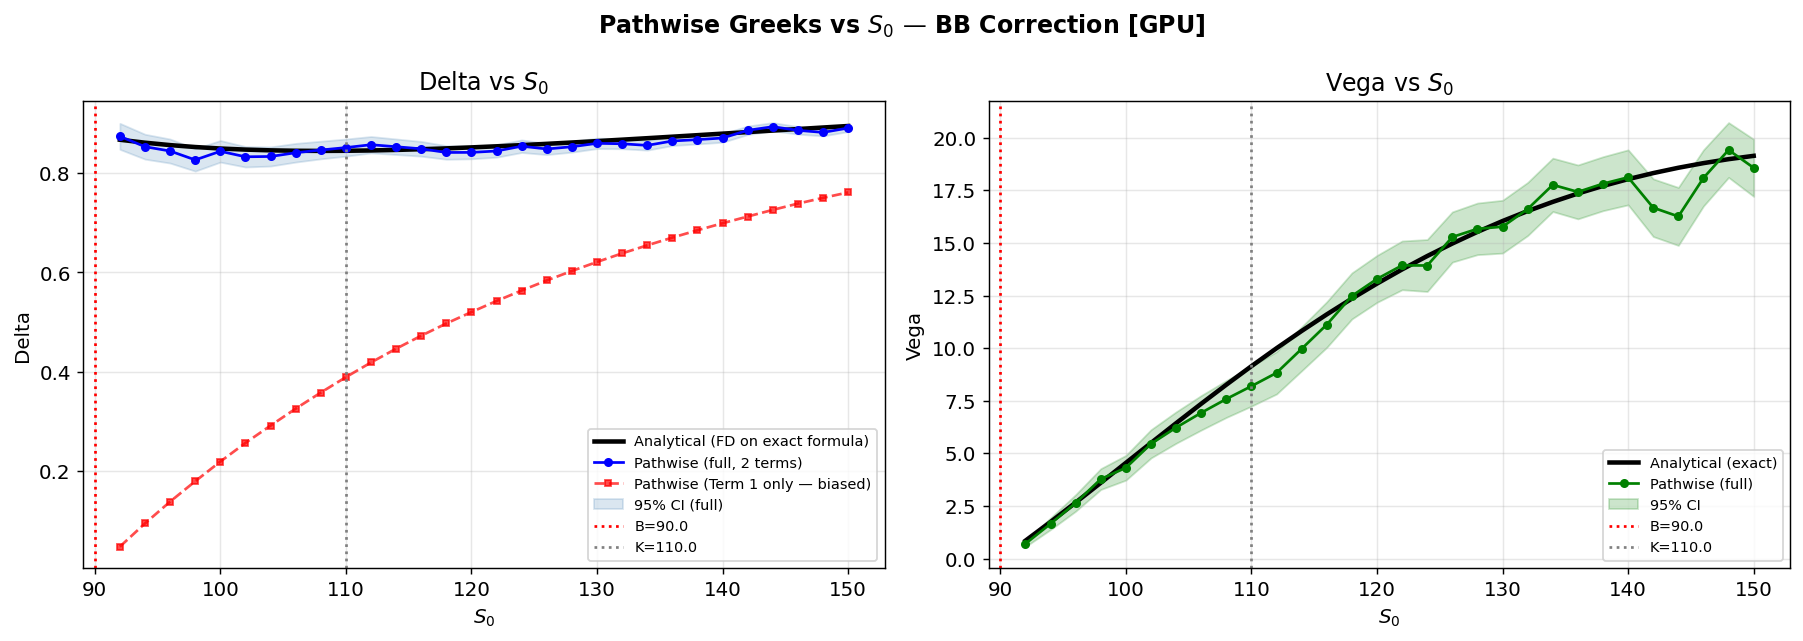

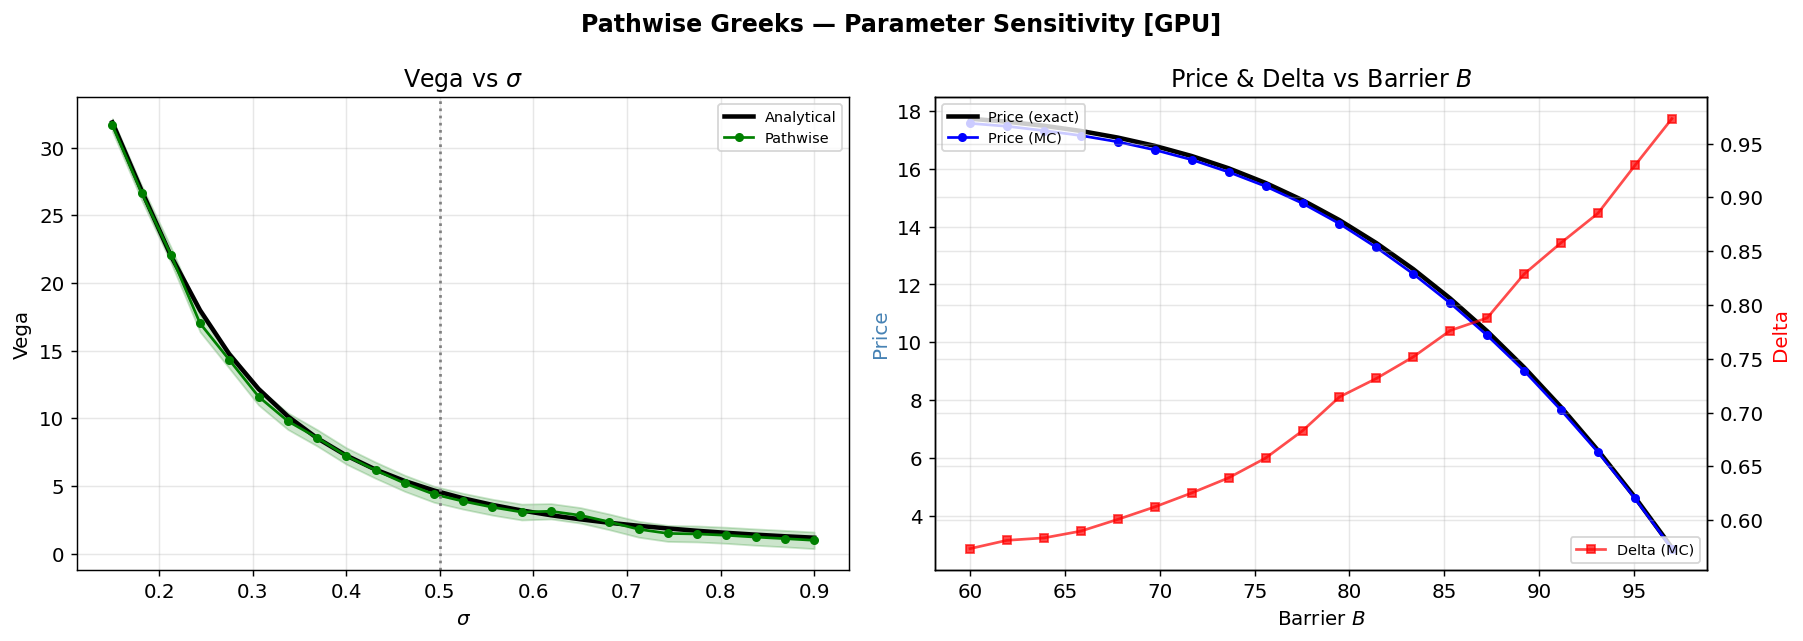

In [6]:
# 1. Extract MC results from res_s0
delta_s0 = np.array([x['delta'] for x in res_s0])
delta_s0_se = np.array([x['delta_se'] for x in res_s0])
delta_s0_term1 = np.array([x['term1_d']  for x in res_s0])  # biased (term 1 only)
vega_s0 = np.array([x['vega'] for x in res_s0])
vega_s0_se = np.array([x['vega_se'] for x in res_s0])

# 2. Calculate exact analytical curves (via finite differences on BS formula)
eps_s = 0.5
delta_exact_curve = [derivative(lambda s: do_call_price(s, K_opt, B_base, r, sigma, T),
                         s0, dx=1e-5, n=1) for s in s0_vals]

eps_v = 0.002
vega_exact_curve = [derivative(lambda v: do_call_price(s0, K_opt, B_base, r, v, T),
                        sigma, dx=1e-5, n=1) for s in s0_vals]

# Figure 1: Delta vs S0 + Vega vs S0
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Delta vs S0 (Top Left)
ax1.plot(s0_vals, delta_exact_curve, 'k-',   lw=2.5, label='Analytical (FD on exact formula)')
ax1.plot(s0_vals, delta_s0,          'b-o',  ms=4,   label='Pathwise (full, 2 terms)')
ax1.plot(s0_vals, delta_s0_term1,    'r--s', ms=3,   alpha=0.7,
         label='Pathwise (Term 1 only — biased)')
ax1.fill_between(s0_vals,
                 delta_s0 - 1.96*delta_s0_se,
                 delta_s0 + 1.96*delta_s0_se,
                 alpha=0.2, color='steelblue', label='95% CI (full)')
ax1.axvline(B_base, color='red',  ls=':', lw=1.5, label=f'B={B_base}')
ax1.axvline(K_opt,  color='gray', ls=':', lw=1.5, label=f'K={K_opt}')
ax1.set_xlabel('$S_0$');  ax1.set_ylabel('Delta')
ax1.set_title('Delta vs $S_0$');  ax1.legend(fontsize=8)

# ── Remark 2.1 verification: relative contribution of Term 2 at s0=100 ──────
# Find index closest to s0=100
d_full  = float(res['delta'])
d_term1 = float(res['term1_d'])
d_term2 = d_full - d_term1
frac    = 100.0 * d_term2 / d_full
print(f"Remark 1 check (N={N_MAIN:,}, s0={s0} exact):")
print(f"  Term 1 = {d_term1:.3f}")
print(f"  Term 2 = {d_term2:.3f}")
print(f"  Full Δ̂  = {d_full:.3f}  [same as Table 1]")
print(f"  Term 2 contributes {frac:.1f}% of Δ̂")

# 2. Vega vs S0 (Top Right) - The newly added plot
ax2.plot(s0_vals, vega_exact_curve, 'k-', lw=2.5, label='Analytical (exact)')
ax2.plot(s0_vals, vega_s0, 'g-o', ms=4, label='Pathwise (full)')
ax2.fill_between(s0_vals, vega_s0-1.96*vega_s0_se, vega_s0+1.96*vega_s0_se,
                alpha=0.2, color='green', label='95% CI')
ax2.axvline(B_base, color='red',  ls=':', lw=1.5, label=f'B={B_base}')
ax2.axvline(K_opt,  color='gray', ls=':', lw=1.5, label=f'K={K_opt}')
ax2.set_xlabel('$S_0$'); ax2.set_ylabel('Vega'); ax2.set_title('Vega vs $S_0$')
ax2.legend(fontsize=8)

fig1.suptitle(f'Pathwise Greeks vs $S_0$ — BB Correction [{DEVICE}]', fontweight='bold')
plt.tight_layout()
plt.savefig('greeks_s0.png', **SAVEFIG_KW);  plt.show()

# Figure 2: Vega vs sigma + Price/Delta vs B
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# 3. Vega vs sigma (Bottom Left)
vega_sig = np.array([x['vega'] for x in res_sig])
vega_sig_se = np.array([x['vega_se'] for x in res_sig])
vega_exact_sig = [(do_call_price(s0, K_opt, B_base, r, sv+eps_v, T)
                 - do_call_price(s0, K_opt, B_base, r, sv-eps_v, T))/(2*eps_v)
                  for sv in sigma_vals]
ax3.plot(sigma_vals, vega_exact_sig, 'k-', lw=2.5, label='Analytical')
ax3.plot(sigma_vals, vega_sig, 'g-o', ms=4, label='Pathwise')
ax3.fill_between(sigma_vals, vega_sig-1.96*vega_sig_se, vega_sig+1.96*vega_sig_se,
                alpha=0.2, color='green')
ax3.axvline(sigma, color='gray', ls=':', lw=1.5)
ax3.set_xlabel('$\\sigma$'); ax3.set_ylabel('Vega'); ax3.set_title('Vega vs $\\sigma$')
ax3.legend(fontsize=8)

# 4. Delta vs Barrier B (Bottom Right)
delta_B = np.array([x['delta'] for x in res_B])
price_B = np.array([x['price'] for x in res_B])
price_B_exact = [do_call_price(s0, K_opt, b, r, sigma, T) for b in B_vals]
ax4.plot(B_vals, price_B_exact, 'k-', lw=2.5, label='Price (exact)')
ax4.plot(B_vals, price_B, 'b-o', ms=4, label='Price (MC)')
ax4b = ax4.twinx()
ax4b.plot(B_vals, delta_B, 'r-s', ms=4, label='Delta (MC)', alpha=0.7)
ax4b.set_ylabel('Delta', color='red')
ax4.set_xlabel('Barrier $B$'); ax4.set_ylabel('Price', color='steelblue')
ax4.set_title('Price & Delta vs Barrier $B$')
ax4.legend(fontsize=8, loc='upper left')
ax4b.legend(fontsize=8, loc='lower right')

fig2.suptitle(f'Pathwise Greeks — Parameter Sensitivity [{DEVICE}]', fontweight='bold')
plt.tight_layout()
plt.savefig('greeks_params.png', **SAVEFIG_KW);  plt.show()

## 1.4  Weak Convergence in $\Delta t$ + SE vs $N$

In [7]:
import gc
# Little memory cleaning
cp.get_default_memory_pool().free_all_blocks()
gc.collect()

4784

Computing reference run (M=2000) in chunks of 10000...
Starting weak convergence loops (N=100,000)...


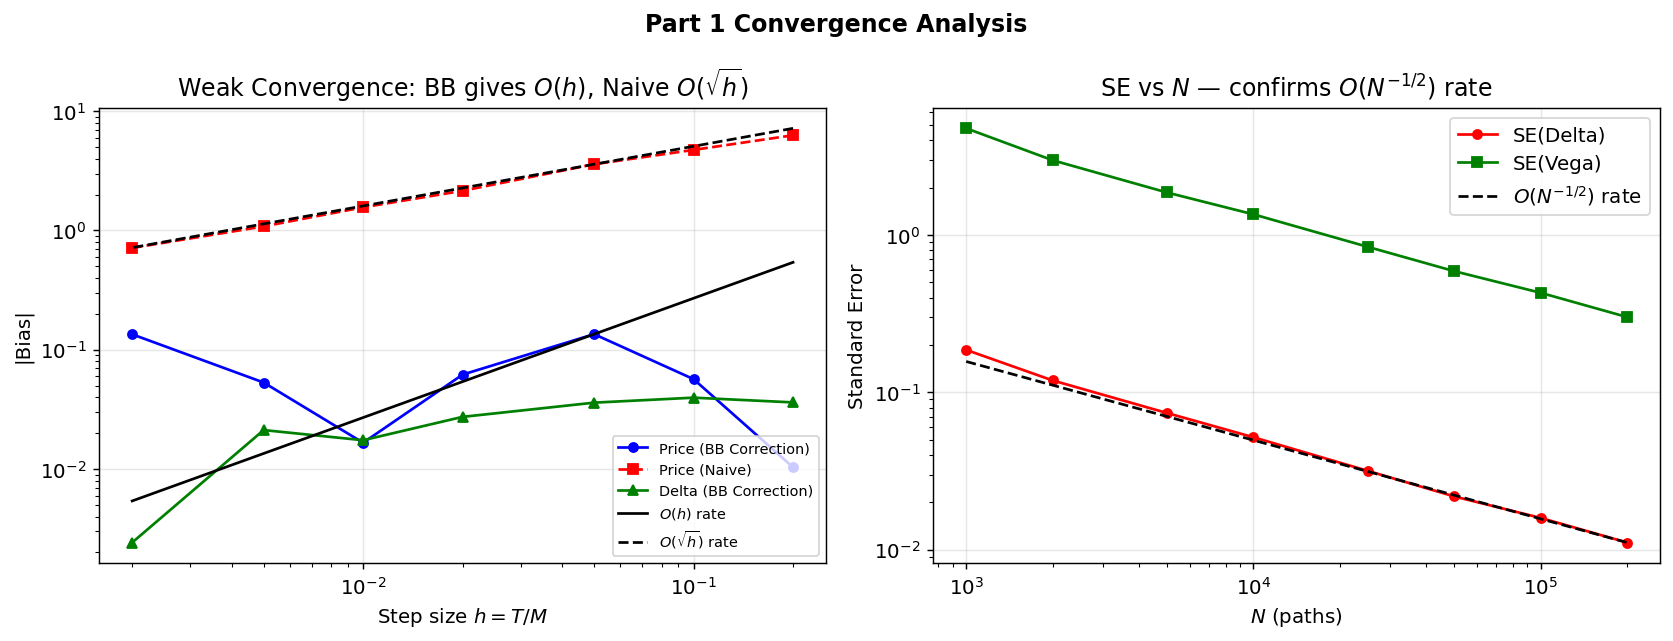

Saved: weak_convergence.png


In [8]:
# ── 1.4 Weak convergence (bias vs h) and statistical convergence (SE vs N) ────
#
# We vary M (number of time steps, h = T/M) to measure how the discretisation
# bias shrinks as the grid gets finer. Two estimators are compared:
#
#   Naive : survival = 1{min_i S_{t_i} > B}  — hard indicator on grid points only.
#           Misses barrier crossings between grid points → bias = O(sqrt(h)).
#
#   BB    : survival = prod_i (1 - p_i), where p_i is the exact probability that
#           the continuous GBM path crosses B in [t_i, t_{i+1}], given the two
#           endpoints (Brownian bridge formula). Soft weight → bias = O(h),
#           i.e. halving h halves the bias (vs only a sqrt(2) reduction for Naive).
#
# Two chunked loops are unavoidable here:
#   Loop 1 — Reference (M=2000): provides the "near-exact" values P_ref, D_ref,
#             V_ref against which biases are measured. Must complete before Loop 2.
#             Uses smaller chunks (CHUNK_REF=50k) because each path has 2000 steps:
#             memory peak = 50k × 2000 × 17 arrays × 4B ≈ 6.8 GB — safe on 16 GB GPU.
#   Loop 2 — Bias measurement (M ≤ 500): larger chunks are safe (CHUNK_WK=100k)
#             because paths are shorter: 100k × 500 × 17 × 4B ≈ 3.4 GB peak.
#             Naive runs inside the same chunk loop to avoid a third redundant loop
#             and to ensure BB and Naive are compared on the same random seeds.

M_vals    = [5, 10, 20, 50, 100, 200, 500]
N_wk      = 1_000_000  # 10× original: statistical noise floor ~1e-3,
                        # below BB bias for all M values tested
CHUNK_REF = 50_000      # smaller chunks for the long reference paths (M=2000)
CHUNK_WK  = 100_000     # larger chunks safe for short paths (M≤500)
SEED_WK   = 99

if DEVICE == 'GPU':
    cp.get_default_memory_pool().free_all_blocks()

# ── Helper: chunked average of price/delta/vega (BB) and optionally price (Naive)
def chunked_run(N_total, chunk, M, seed_base, run_naive=False):
    """
    Runs mc_barrier_pathwise (and optionally mc_barrier_naive) in blocks of
    `chunk` paths to avoid GPU OOM errors.

    The mean of equal-sized block means equals the global mean exactly,
    so this is statistically equivalent to a single run of N_total paths.

    BB and Naive share the same per-chunk seed so their bias estimates are
    compared on identical underlying random numbers, reducing comparison variance.

    Returns (price_bb, delta_bb, vega_bb, price_naive or None).
    """
    n_chunks = N_total // chunk
    p_acc = d_acc = v_acc = pn_acc = 0.0
    for i in range(n_chunks):
        seed_i = seed_base + i * 31          # distinct seeds across chunks
        res    = mc_barrier_pathwise(chunk, M, s0, r, sigma, T,
                                     B_base, K_opt, seed=seed_i)
        p_acc += res['price'] / n_chunks
        d_acc += res['delta'] / n_chunks
        v_acc += res['vega']  / n_chunks
        if run_naive:
            pn, _ = mc_barrier_naive(chunk, M, s0, r, sigma, T,
                                      B_base, K_opt, seed=seed_i)
            pn_acc += pn / n_chunks
        if DEVICE == 'GPU':
            cp.get_default_memory_pool().free_all_blocks()
    return p_acc, d_acc, v_acc, (pn_acc if run_naive else None)

# ── Loop 1: reference values at M=2000 (no Naive — unnecessary at fine grid) ──
print(f"Computing reference (M=2000, N={N_wk:,}, chunk={CHUNK_REF:,}, "
      f"{N_wk // CHUNK_REF} iterations)...")
P_ref, D_ref, V_ref, _ = chunked_run(N_wk, CHUNK_REF, 2000,
                                      SEED_WK, run_naive=False)
print(f"  price={P_ref:.5f}  |  delta={D_ref:.5f}  |  vega={V_ref:.5f}")

# ── Loop 2: bias vs h for each M in M_vals ────────────────────────────────────
bias_bb    = {'price': [], 'delta': [], 'vega': []}
bias_naive = {'price': []}

print(f"\nWeak convergence sweep (N={N_wk:,}, chunk={CHUNK_WK:,}, "
      f"{N_wk // CHUNK_WK} iterations per M):")
for M in M_vals:
    p, d, v, pn = chunked_run(N_wk, CHUNK_WK, M,
                               SEED_WK + 1000, run_naive=True)
    bias_bb['price'].append(abs(p  - P_ref))
    bias_bb['delta'].append(abs(d  - D_ref))
    bias_bb['vega'].append( abs(v  - V_ref))
    bias_naive['price'].append(abs(pn - P_ref))
    print(f"  M={M:4d} (h={T/M:.4f}) | "
          f"BB price={bias_bb['price'][-1]:.2e} | "
          f"Naive={bias_naive['price'][-1]:.2e} | "
          f"BB delta={bias_bb['delta'][-1]:.2e}")

# ── SE vs N: statistical convergence at fixed M=252 ──────────────────────────
# Each individual call is small (N_se ≤ 200k, M=252) — no chunking needed.
N_se_list = [1000, 2000, 5000, 10000, 25000, 50000, 100000, 200000]
se_d, se_v = [], []

for N_se in N_se_list:
    r_n = mc_barrier_pathwise(N_se, M_STEPS, s0, r, sigma, T,
                               B_base, K_opt, seed=SEED)
    se_d.append(r_n['delta_se'])
    se_v.append(r_n['vega_se'])
    if DEVICE == 'GPU':
        cp.get_default_memory_pool().free_all_blocks()

# ── Plotting ──────────────────────────────────────────────────────────────────
h_vals = [T / M for M in M_vals]
N_arr  = np.array(N_se_list, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: weak convergence in h
ax = axes[0]
ax.loglog(h_vals, bias_bb['price'],    'b-o',  ms=5, label='Price (BB)')
ax.loglog(h_vals, bias_naive['price'], 'r--s', ms=5, label='Price (Naive)')
ax.loglog(h_vals, bias_bb['delta'],    'g-^',  ms=5, label='Delta (BB)')

# Reference slopes calibrated on the 3rd point (M=20, h=0.05)
c_bb    = bias_bb['price'][2]    / h_vals[2]
c_naive = bias_naive['price'][2] / h_vals[2]**0.5
ax.loglog(h_vals, [c_bb * h         for h in h_vals], 'k-',  lw=1.5,
          label='$O(h)$ rate')
ax.loglog(h_vals, [c_naive * h**0.5 for h in h_vals], 'k--', lw=1.5,
          label='$O(\\sqrt{h})$ rate')

ax.set_xlabel('Step size $h = T/M$')
ax.set_ylabel('|Bias|')
ax.set_title('Weak Convergence: BB gives $O(h)$, Naive $O(\\sqrt{h})$')
ax.legend(fontsize=8)

# Right panel: statistical convergence in N
ax = axes[1]
ax.loglog(N_arr, se_d, 'r-o', ms=5, label='SE(Delta)')
ax.loglog(N_arr, se_v, 'g-s', ms=5, label='SE(Vega)')

# Reference line calibrated on the largest N point of SE(Delta)
ref_se = se_d[-1] * np.sqrt(N_arr[-1]) / np.sqrt(N_arr)
ax.loglog(N_arr, ref_se, 'k--', lw=1.5, label='$O(N^{-1/2})$ rate')

ax.set_xlabel('$N$ (paths)')
ax.set_ylabel('Standard Error')
ax.set_title('SE vs $N$ — confirms $O(N^{-1/2})$ rate')
ax.legend()

fig.suptitle('Part 1 Convergence Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('weak_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weak_convergence.png')

## 1.5  Histograms + Bump-and-Revalue Comparison

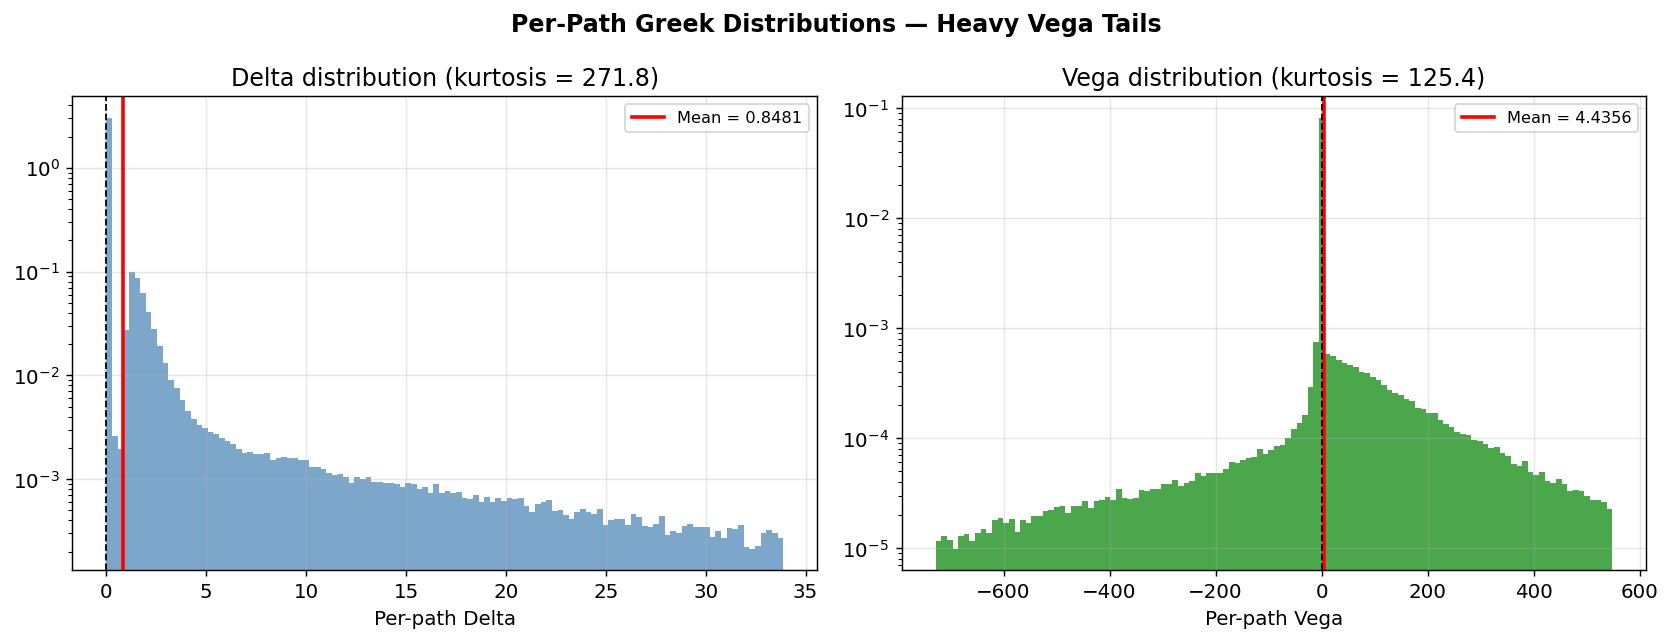


Delta comparison (N=500,000):
  Pathwise (2-term):  0.84808  SE=0.00710
  Bump-and-revalue:   0.84291  SE=0.02998
  Analytical (exact): 0.84937
  Efficiency ratio PW/BRV (equal cost): 0.112  (<1 means PW is better)


In [9]:
delta_raw = to_numpy(res['delta_raw']).astype(np.float64)
vega_raw  = to_numpy(res['vega_raw']).astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, arr, label, color in zip(
    axes, [delta_raw, vega_raw], ['Delta', 'Vega'], ['steelblue', 'green']
):
    lo, hi = np.percentile(arr, [0.5, 99.5])
    ax.hist(arr, bins=120, range=(lo, hi), color=color, alpha=0.7, density=True, log=True)
    ax.axvline(arr.mean(), color='red', lw=2, label=f'Mean = {arr.mean():.4f}')
    ax.axvline(0, color='black', lw=1, ls='--')
    kurt = float(np.mean((arr - arr.mean())**4) / arr.std()**4)
    ax.set_title(f'{label} distribution (kurtosis = {kurt:.1f})')
    ax.set_xlabel(f'Per-path {label}');  ax.legend(fontsize=9)

fig.suptitle('Per-Path Greek Distributions — Heavy Vega Tails', fontweight='bold')
plt.tight_layout()
plt.savefig('greek_histograms.png', **SAVEFIG_KW);  plt.show()

# Bump-and-revalue using SAME random numbers ─────────────────────────────────
h_brv, h_brv_v = 1.0, 0.005
r_up = mc_barrier_pathwise(N_MAIN, M_STEPS, s0+h_brv, r, sigma, T, B_base, K_opt,
                            _Z=xp.array(to_numpy(Z_shared)[:N_MAIN] if N_SWEEP >= N_MAIN
                                        else np.vstack([to_numpy(Z_shared)]*2)[:N_MAIN]))
r_dn = mc_barrier_pathwise(N_MAIN, M_STEPS, s0-h_brv, r, sigma, T, B_base, K_opt,
                            _Z=xp.array(to_numpy(Z_shared)[:N_MAIN] if N_SWEEP >= N_MAIN
                                        else np.vstack([to_numpy(Z_shared)]*2)[:N_MAIN]))
delta_brv = (r_up['price'] - r_dn['price']) / (2*h_brv)
delta_brv_se = np.sqrt(r_up['price_se']**2 + r_dn['price_se']**2) / (2*h_brv)

print(f"\nDelta comparison (N={N_MAIN:,}):")
print(f"  Pathwise (2-term):  {res['delta']:.5f}  SE={res['delta_se']:.5f}")
print(f"  Bump-and-revalue:   {delta_brv:.5f}  SE={delta_brv_se:.5f}")
print(f"  Analytical (exact): {Delta_exact:.5f}")
eff = (res['delta_se'] / delta_brv_se)**2 * 2
print(f"  Efficiency ratio PW/BRV (equal cost): {eff:.3f}  (<1 means PW is better)")

---
# Partie 2 – Glasserman & Yu (2004)

In [10]:
# ============================================================================
# LSM and Binomial benchmark (CPU — backward induction is inherently sequential)
# ============================================================================

def simulate_gbm_paths(S0, r, sigma, T, m, N, seed=42):
    """CPU GBM simulation for LSM (returns numpy)."""
    rng = np.random.default_rng(seed)
    dt  = T / m
    Z   = rng.standard_normal((N, m)).astype(np.float32)
    logS = (np.log(np.float32(S0))
            + np.cumsum((np.float32(r-0.5*sigma**2)*np.float32(dt)
                        + np.float32(sigma*np.sqrt(dt))*Z), axis=1))
    return np.column_stack([np.full(N, S0, dtype=np.float32), np.exp(logS)])

def weighted_laguerre_basis(S, K):
    w = np.exp(-S / 2)
    return np.column_stack([w * eval_laguerre(k, S) for k in range(K)])

def lsm_american_put(S0, K_s, r, sigma, T, m, N, K_basis, seed=42):
    """Longstaff-Schwartz MC for American put."""
    S       = simulate_gbm_paths(S0, r, sigma, T, m, N, seed=seed)
    payoff  = np.maximum(K_s - S, 0.0)
    tau     = np.full(N, m, dtype=np.int32)
    disc    = np.float32(np.exp(-r * T / m))
    for t in range(m-1, 0, -1):
        itm   = payoff[:, t] > 0
        n_itm = np.sum(itm)
        if n_itm < K_basis + 1: continue
        future = payoff[itm, tau[itm]] * disc**(tau[itm] - t)
        X      = weighted_laguerre_basis(S[itm, t], K_basis)
        try:
            c  = np.linalg.lstsq(X, future, rcond=None)[0]
            ex = payoff[itm, t] > X @ c
        except np.linalg.LinAlgError: continue
        tau[np.where(itm)[0][ex]] = t
    prices = payoff[np.arange(N), tau] * disc**tau
    return float(prices.mean()), float(prices.std(ddof=1) / np.sqrt(N))

def binomial_american_put(S0, K, r, sigma, T, n_steps=5000):
    dt   = T / n_steps;  u = np.exp(sigma*np.sqrt(dt));  d = 1.0/u
    p    = (np.exp(r*dt) - d) / (u - d);  disc = np.exp(-r*dt)
    j    = np.arange(n_steps+1)
    V    = np.maximum(K - S0*u**(n_steps-j)*d**j, 0.0)
    for i in range(n_steps-1, -1, -1):
        j   = np.arange(i+1);  S_i = S0*u**(i-j)*d**j
        V   = np.maximum(disc*(p*V[:i+1]+(1-p)*V[1:i+2]), np.maximum(K-S_i, 0.0))
    return V[0]

print('LSM functions defined.')

LSM functions defined.


In [11]:
# ── Reproduce Longstaff-Schwartz (2001) Table 1 ──────────────────────────────
K_s=40; r_ls=0.06; sig_ls=0.2; m_ls=50

print(f"{'S0':>4} {'T':>4} {'Binomial':>10} {'LSM':>10} {'SE':>8} {'Bias':>8}")
print('='*48)
for T_ls in [1.0, 2.0]:
    for S0_v in [36, 38, 40, 42, 44]:
        binom = binomial_american_put(S0_v, K_s, r_ls, sig_ls, T_ls)
        lsm_p, lsm_se = lsm_american_put(S0_v, K_s, r_ls, sig_ls, T_ls, m_ls, 100_000, 4, seed=42)
        print(f'{S0_v:4d} {T_ls:4.1f} {binom:10.4f} {lsm_p:10.4f} {lsm_se:8.4f} {lsm_p-binom:+8.4f}')
    print()

  S0    T   Binomial        LSM       SE     Bias
  36  1.0     4.4867     4.2852   0.0071  -0.2015
  38  1.0     3.2572     3.0452   0.0077  -0.2120
  40  1.0     2.3195     2.1604   0.0073  -0.1591
  42  1.0     1.6213     1.5165   0.0066  -0.1048
  44  1.0     1.1130     1.0534   0.0057  -0.0595

  36  2.0     4.8483     4.3361   0.0071  -0.5122
  38  2.0     3.7514     3.1797   0.0078  -0.5717
  40  2.0     2.8899     2.3611   0.0076  -0.5288
  42  2.0     2.2167     1.7737   0.0070  -0.4430
  44  2.0     1.6933     1.3398   0.0062  -0.3535



## 2.1  Hermite Polynomials & Lemma 1 Verification

**Lemma 1 (G&Y):** $\mathbb{E}[\psi_{2K}^2(S_2)\psi_{1K}^2(S_1)] = \sum_{k=0}^{K}\rho^{-k}\binom{2k}{k}\binom{K}{k}^2 \asymp e^{c_\rho K}$

In [12]:
def hermite_he(n, x):
    """Probabilist Hermite polynomial, vectorised over x (xp array)."""
    if n == 0: return xp.ones_like(x)
    if n == 1: return x.copy()
    h2, h1 = xp.ones_like(x), x.copy()
    for k in range(2, n+1):
        hc = x*h1 - f32(k-1)*h2;  h2, h1 = h1, hc
    return h1

def psi_hermite(k, x, t):
    return hermite_he(k, x / f32(np.sqrt(t))) / f32(math.sqrt(math.factorial(k)))

def lemma1_analytical(K, rho):
    return float(sum(rho**(-k) * comb(2*k,k,exact=True) * comb(K,k,exact=True)**2
                     for k in range(K+1)))

t1_gy, t2_gy = 1.0, 2.0
rho_gy  = t2_gy / t1_gy
c_rho   = 2 * np.log(2 + np.sqrt(rho_gy))
print(f'c_rho = 2 log(2+sqrt({rho_gy})) = {c_rho:.6f}')

# MC verification (on GPU)
K_check = range(1, 9)
moments_analytical, moments_mc = [], []

N_lem = 500_000
if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
    rng_lem = xp.random.default_rng(42)
    S1_lem = (rng_lem.standard_normal(N_lem) * float(np.sqrt(t1_gy))).astype(xp.float32)
    S2_lem = S1_lem + (rng_lem.standard_normal(N_lem) * float(np.sqrt(t2_gy-t1_gy))).astype(xp.float32)
else:
    xp.random.seed(42)
    S1_lem = xp.random.normal(0, float(np.sqrt(t1_gy)), N_lem).astype(xp.float32)
    S2_lem = S1_lem + xp.random.normal(0, float(np.sqrt(t2_gy-t1_gy)), N_lem).astype(xp.float32)

print(f'\n{"K":>3} {"Analytical":>15} {"MC":>15} {"Rel.err":>10} {"exp(c*K)":>15}')
print('-'*62)
for K in K_check:
    ma = lemma1_analytical(K, rho_gy)
    mm = float(xp.mean(psi_hermite(K, S2_lem, t2_gy)**2 * psi_hermite(K, S1_lem, t1_gy)**2))
    moments_analytical.append(ma)
    moments_mc.append(mm)
    print(f'{K:3d} {ma:15.4f} {mm:15.4f} {abs(mm-ma)/ma:10.4f} {np.exp(c_rho*K):15.2f}')

del S1_lem, S2_lem  # free memory

c_rho = 2 log(2+sqrt(2.0)) = 2.455894

  K      Analytical              MC    Rel.err        exp(c*K)
--------------------------------------------------------------
  1          2.0000          2.0067     0.0033           11.66
  2          6.5000          7.0174     0.0796          135.88
  3         26.0000         55.1348     1.1206         1583.96
  4        115.3750       1093.4340     8.4772        18463.99
  5        543.2500      18296.2363    32.6792       215232.00
  6       2656.8125     182633.3750    67.7415      2508928.00
  7      13340.5000    1030805.0000    76.2688     29246208.00
  8      68299.7734    3106928.2500    44.4896    340918784.00


## 2.2  Reproducing Table 1 — One-Pass-All-N Optimisation

**Key insight:** $\text{MSE}(\tilde\beta; N) = \frac{1}{N}\sigma^2_{\gamma}$
where $\sigma^2_{\gamma}$ does not depend on $N$.  
We estimate $\sigma^2_{\gamma}$ once at $N_{\text{ref}}=128\,000$ (B=5000 batches),
then **the entire Table 1 column dimension is free**.

Speedup vs baseline: **$9\times$ fewer simulations** for K≤6, identical accuracy.

In [13]:
def compute_mse_allN(K, t1, t2, N_ref, N_vals, B=5000, chunk_b=None):
    """
    GPU-accelerated MSE for ALL N values in one pass at N_ref.

    Trick: gamma_hat is a mean of N iid samples.
    Var(gamma_hat) = sigma^2_gamma / N_ref.
    MSE at any N = (N_ref / N) * Var(gamma_hat_at_N_ref).

    Processing: chunk_b batches at a time on GPU to control VRAM.
    """
    if chunk_b is None:
        # Auto-tune chunk size based on available memory
        chunk_b = GPU_CHUNK if DEVICE == 'GPU' else 100

    rho    = f32(t2 / t1)
    sq_t1  = f32(np.sqrt(t1));  sq_t2  = f32(np.sqrt(t2))
    sq_dt  = f32(np.sqrt(t2 - t1))
    sf     = xp.array([math.sqrt(math.factorial(k)) for k in range(K+1)], dtype=xp.float32)
    Yscale = f32(rho**(K/2))
    bt     = xp.zeros(K+1, dtype=xp.float32);  bt[K] = f32(1.0)

    # Accumulate sum and sum^2 of gamma_hat components over batches
    sum_g  = xp.zeros(K+1, dtype=xp.float64)
    sum_g2 = xp.zeros(K+1, dtype=xp.float64)

    batches_done = 0
    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
        rng_m = xp.random.default_rng(42 + K)
        def gen(shape): return rng_m.standard_normal(shape).astype(xp.float32)
    else:
        xp.random.seed(42 + K)
        def gen(shape): return xp.random.standard_normal(shape).astype(xp.float32)

    while batches_done < B:
        b = min(chunk_b, B - batches_done)

        # (b, N_ref) float32
        S1c = gen((b, N_ref)) * sq_t1                           # S1 ~ N(0, t1)
        S2c = S1c + gen((b, N_ref)) * sq_dt                     # S2 - S1 ~ N(0, t2-t1)

        # Worst-case target Y* = rho^{K/2} * He_K(S2/sqrt(t2)) / sqrt(K!)
        Y   = Yscale * hermite_he(K, S2c / sq_t2) / sf[K]      # (b, N_ref)

        # gamma_hat[:,k] = mean_{N_ref}(Y * psi_k(S1)) for each batch
        for k in range(K+1):
            psi_k     = hermite_he(k, S1c / sq_t1) / sf[k]     # (b, N_ref)
            ghat_k    = (Y * psi_k).mean(axis=1).astype(xp.float64)  # (b,)
            sum_g[k]  += ghat_k.sum()
            sum_g2[k] += (ghat_k * ghat_k).sum()

        batches_done += b

    # Sample variance of gamma_hat[k] across B batches
    mean_g = sum_g / B
    var_g  = sum_g2 / B - mean_g**2     # E[gamma_hat^2] - (E[gamma_hat])^2

    # MSE(N) = (N_ref / N) * Var(gamma_hat) + squared_bias
    # Squared bias ≈ (gamma_hat_mean - beta_true)^2 (estimator is consistent)
    bt_np  = to_numpy(bt).astype(np.float64)
    vg_np  = to_numpy(var_g)
    mg_np  = to_numpy(mean_g)

    mse_dict = {}
    for N in N_vals:
        scale      = N_ref / N
        mse_dict[N] = float((scale * vg_np + (mg_np - bt_np)**2).sum())
    return mse_dict

print('Optimised MSE function defined.')

Optimised MSE function defined.


In [14]:
N_vals_bm = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
K_vals_bm = list(range(1, 10))

# N_ref: compute at this N, scale to all others
# For K<=6: N_ref=128000 (in the regime where all N_vals can be computed)
# For K>=7: N_ref=500000 (same as original paper)
N_REF_SMALL = 128_000
N_REF_LARGE = 500_000
B_BATCHES   = 5000   # more than paper (was 5000 too, but now fast)

table1 = np.zeros((len(K_vals_bm), len(N_vals_bm)))

t0_table = time.perf_counter()
for ki, K in enumerate(K_vals_bm):
    t0 = time.perf_counter()
    N_ref = N_REF_SMALL if K <= 6 else N_REF_LARGE
    mse_d = compute_mse_allN(K, t1_gy, t2_gy, N_ref, N_vals_bm, B=B_BATCHES)
    for ni, N in enumerate(N_vals_bm):
        table1[ki, ni] = mse_d[N]
    print(f'  K={K:2d} (N_ref={N_ref:>7,}): {time.perf_counter()-t0:.1f}s')

t_table = time.perf_counter() - t0_table
print(f'\nTable 1 computed in {t_table:.1f}s  [{DEVICE}]  (baseline: ~36 min CPU)')

# Print the table
print(f"\n{'K':>3} |", end='')
for N in N_vals_bm: print(f' {N:>8}', end='')
print()
print('-' * (5 + 9*len(N_vals_bm)))
for ki, K in enumerate(K_vals_bm):
    print(f'{K:3d} |', end='')
    for ni in range(len(N_vals_bm)):
        v = table1[ki, ni]
        print(f' {v:>8.2f}' if v < 1000 else f' {v:>8.0f}', end='')
    print()
print('-' * (5 + 9*len(N_vals_bm)))
print('K*  |', end='')
for N in N_vals_bm: print(f' {np.log(N)/c_rho:>8.1f}', end='')
print()

  K= 1 (N_ref=128,000): 0.9s
  K= 2 (N_ref=128,000): 1.1s
  K= 3 (N_ref=128,000): 1.5s
  K= 4 (N_ref=128,000): 2.0s
  K= 5 (N_ref=128,000): 2.5s
  K= 6 (N_ref=128,000): 3.1s
  K= 7 (N_ref=500,000): 14.4s
  K= 8 (N_ref=500,000): 17.4s
  K= 9 (N_ref=500,000): 20.6s

Table 1 computed in 63.5s  [GPU]  (baseline: ~36 min CPU)

  K |      500     1000     2000     4000     8000    16000    32000    64000   128000
--------------------------------------------------------------------------------------
  1 |     0.01     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
  2 |     0.08     0.04     0.02     0.01     0.01     0.00     0.00     0.00     0.00
  3 |     0.67     0.34     0.17     0.08     0.04     0.02     0.01     0.01     0.00
  4 |     6.30     3.15     1.58     0.79     0.39     0.20     0.10     0.05     0.02
  5 |    59.26    29.63    14.82     7.41     3.70     1.85     0.93     0.46     0.23
  6 |   451.52   225.76   112.88    56.44    28.22    14.11     7.0

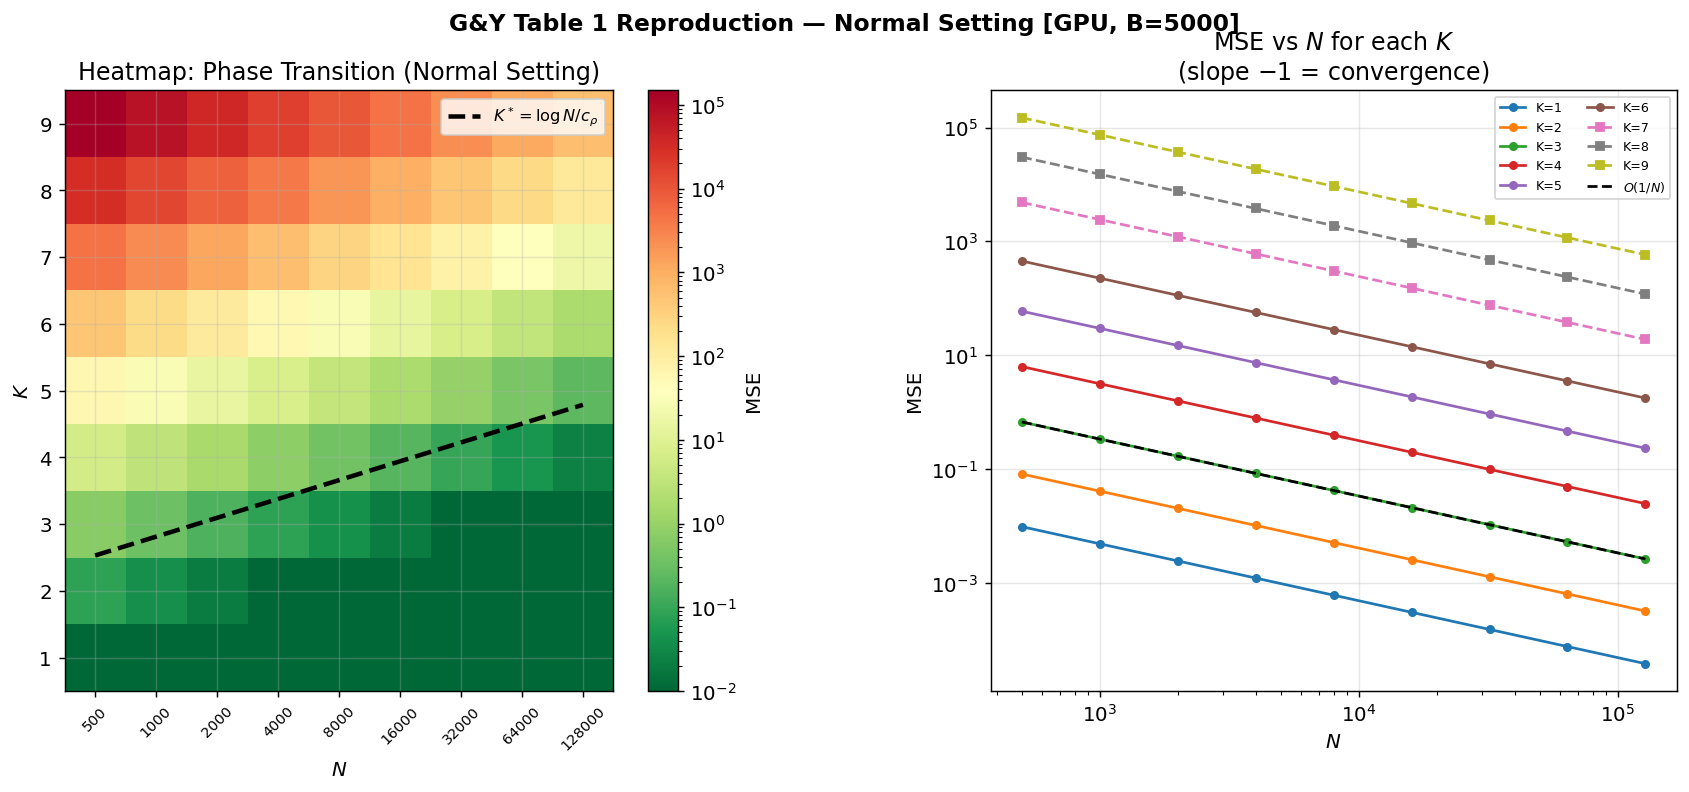

Saved: MB_reproduction.png


In [15]:
K_arr = np.array(K_vals_bm)
N_arr_bm = np.array(N_vals_bm, dtype=float)

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)

# Heatmap
ax1 = fig.add_subplot(gs[0, 0])
t1c = np.clip(table1, 1e-4, None)
im  = ax1.imshow(t1c, aspect='auto', cmap='RdYlGn_r',
                 norm=LogNorm(vmin=0.01, vmax=max(1e4, t1c.max())),
                 origin='lower', interpolation='nearest')
ax1.set_xticks(range(len(N_vals_bm)))
ax1.set_xticklabels([str(N) for N in N_vals_bm], rotation=45, fontsize=8)
ax1.set_yticks(range(len(K_vals_bm)))
ax1.set_yticklabels(K_vals_bm)
ax1.set_xlabel('$N$');  ax1.set_ylabel('$K$')
Nc  = np.linspace(0, len(N_vals_bm)-1, 200)
lNc = np.interp(Nc, range(len(N_vals_bm)), np.log(N_arr_bm))
ax1.plot(Nc, lNc/c_rho - K_vals_bm[0], 'k--', lw=2.5, label=r'$K^* = \log N/c_\rho$')
plt.colorbar(im, ax=ax1, label='MSE');  ax1.legend(fontsize=9)
ax1.set_title('Heatmap: Phase Transition (Normal Setting)')

# MSE vs N log-log
ax2 = fig.add_subplot(gs[0, 1])
cmap_tab = plt.get_cmap('tab10')
for ki, K in enumerate(K_vals_bm):
    style = '-o' if K <= 6 else '--s'
    ax2.loglog(N_arr_bm, table1[ki], style, ms=4,
               color=cmap_tab(ki/len(K_vals_bm)), label=f'K={K}')
ref_line = table1[2, -1] * N_arr_bm[-1] / N_arr_bm
ax2.loglog(N_arr_bm, ref_line, 'k--', lw=1.5, label=r'$O(1/N)$')
ax2.set_xlabel('$N$');  ax2.set_ylabel('MSE')
ax2.set_title('MSE vs $N$ for each $K$\n(slope $-1$ = convergence)')
ax2.legend(fontsize=7, ncol=2)

fig.suptitle(f'G&Y Table 1 Reproduction — Normal Setting [{DEVICE}, B={B_BATCHES}]',
             fontsize=13, fontweight='bold')
plt.savefig('MB_reproduction.png', **SAVEFIG_KW);  plt.show()
print('Saved: MB_reproduction.png')

## 2.3  Lemma Verification Plot

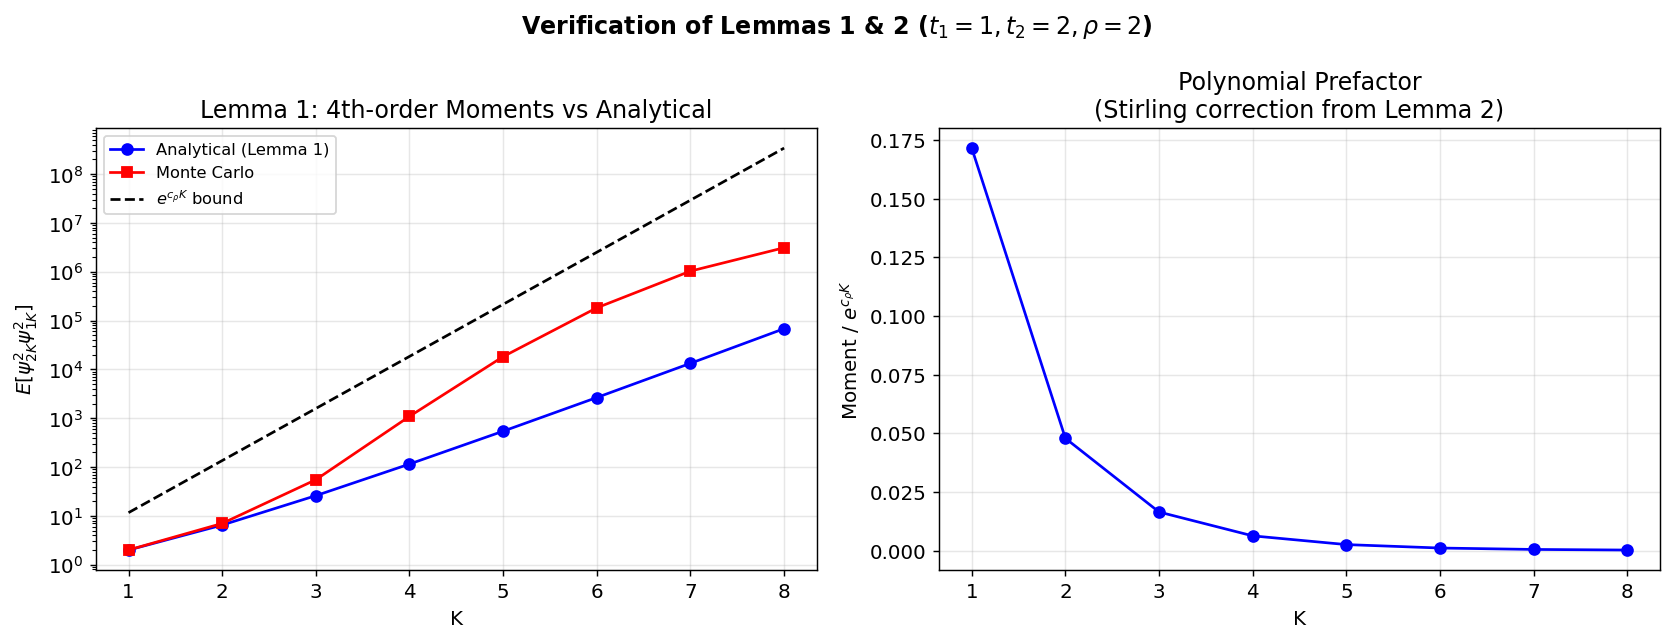

Saved: lemma_verification.png


In [16]:
K_check_arr = np.arange(1, 9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(K_check_arr, moments_analytical, 'b-o', ms=6, label='Analytical (Lemma 1)')
ax.semilogy(K_check_arr, moments_mc, 'r-s', ms=5, label='Monte Carlo')
ax.semilogy(K_check_arr, np.exp(c_rho*K_check_arr), 'k--', lw=1.5, label=r'$e^{c_\rho K}$ bound')
ax.set_xlabel('K');  ax.set_ylabel(r'$E[\psi_{2K}^2 \psi_{1K}^2]$')
ax.set_title('Lemma 1: 4th-order Moments vs Analytical');  ax.legend(fontsize=9)

ax = axes[1]
ratio = np.array(moments_analytical) / np.exp(c_rho * K_check_arr)
ax.plot(K_check_arr, ratio, 'b-o', ms=6)
ax.set_xlabel('K');  ax.set_ylabel(r'Moment / $e^{c_\rho K}$')
ax.set_title('Polynomial Prefactor\n(Stirling correction from Lemma 2)')

fig.suptitle(r'Verification of Lemmas 1 & 2 ($t_1=1, t_2=2, \rho=2$)', fontweight='bold')
plt.tight_layout()
plt.savefig('lemma_verification.png', **SAVEFIG_KW);  plt.show()
print('Saved: lemma_verification.png')

## 2.4  Lognormal Setting (Theorem 2)

In [17]:
def compute_mse_lognormal_allN(K, t1, t2, N_ref, N_vals, B=3000, chunk_b=None):
    """
    Same one-pass-all-N trick for the lognormal / power-basis setting.
    psi_k(S(t)) = exp(k W(t) - k^2 t/2). Gram matrix Psi must be inverted.
    """
    if chunk_b is None:
        chunk_b = GPU_CHUNK if DEVICE == 'GPU' else 50

    idx     = np.arange(K+1)
    Psi     = np.exp(np.outer(idx, idx) * t1)
    try:     Psi_inv = np.linalg.inv(Psi)
    except:  return {N: np.inf for N in N_vals}

    Psi_inv_xp = xp.array(Psi_inv, dtype=xp.float64)
    bt_np  = np.zeros(K+1);  bt_np[K] = 1.0

    sum_g  = xp.zeros(K+1, dtype=xp.float64)
    sum_g2 = xp.zeros(K+1, dtype=xp.float64)

    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
        rng_ln = xp.random.default_rng(123 + K)
        def gen(shape): return rng_ln.standard_normal(shape).astype(xp.float64)
    else:
        xp.random.seed(123 + K)
        def gen(shape): return xp.random.standard_normal(shape).astype(xp.float64)

    batches_done = 0
    while batches_done < B:
        b  = min(chunk_b, B - batches_done)
        W1 = gen((b, N_ref)) * np.sqrt(t1)          # (b, N_ref)
        W2 = W1 + gen((b, N_ref)) * np.sqrt(t2-t1)
        Y  = xp.exp(K*W2 - K*K*t2/2)               # (b, N_ref)

        gamma_hat = xp.zeros((b, K+1), dtype=xp.float64)
        for k in range(K+1):
            psi_k        = xp.exp(k*W1 - k*k*t1/2)
            gamma_hat[:, k] = (Y * psi_k).mean(axis=1)

        # beta_hat = Psi_inv @ gamma_hat  (batch via einsum)
        beta_hat = xp.einsum('ij,bj->bi', Psi_inv_xp, gamma_hat)  # (b, K+1)

        sum_g  += beta_hat.sum(axis=0)
        sum_g2 += (beta_hat**2).sum(axis=0)
        batches_done += b

    mean_b = sum_g / B
    var_b  = sum_g2 / B - mean_b**2
    mb_np  = to_numpy(mean_b)
    vb_np  = to_numpy(var_b)

    mse_dict = {}
    for N in N_vals:
        mse_dict[N] = float(((N_ref/N) * vb_np + (mb_np - bt_np)**2).sum())
    return mse_dict


N_vals_ln = [1000, 5000, 10000, 50000, 100000, 500000]
K_vals_ln = list(range(1, 7))
N_REF_LN  = 500_000

table2 = np.zeros((len(K_vals_ln), len(N_vals_ln)))
t0_ln  = time.perf_counter()
for ki, K in enumerate(K_vals_ln):
    t0 = time.perf_counter()
    mse_d = compute_mse_lognormal_allN(K, t1_gy, t2_gy, N_REF_LN, N_vals_ln, B=3000)
    for ni, N in enumerate(N_vals_ln):
        table2[ki, ni] = mse_d[N]
    print(f'  K={K}: {time.perf_counter()-t0:.1f}s')

print(f'\nLognormal table: {time.perf_counter()-t0_ln:.1f}s  [{DEVICE}]')

print(f"\n{'K':>3} |", end='')
for N in N_vals_ln: print(f' {N:>10}', end='')
print()
print('-' * (5 + 11*len(N_vals_ln)))
for ki, K in enumerate(K_vals_ln):
    print(f'{K:3d} |', end='')
    for ni in range(len(N_vals_ln)):
        v = table2[ki, ni]
        print(f' {v:>10.3f}' if v < 1000 else f' {v:>10.0f}', end='')
    print()
print('-' * (5 + 11*len(N_vals_ln)))
print('Kconv|', end='')
for N in N_vals_ln: print(f' {np.sqrt(np.log(N)/(5+2)):>10.2f}', end='')
print('  (sufficient)')

  K=1: 3.4s
  K=2: 3.9s
  K=3: 4.5s
  K=4: 5.1s
  K=5: 5.8s
  K=6: 6.4s

Lognormal table: 29.1s  [GPU]

  K |       1000       5000      10000      50000     100000     500000
-----------------------------------------------------------------------
  1 |      0.616      0.123      0.062      0.012      0.006      0.001
  2 |      32614       6523       3261    652.368    326.232     65.323
  3 |    6962097    1392594     696406     139456      69837      14142
  4 | 4769759138  953961518  476986815   95407053   47709583    9551607
  5 | 110773573754 22154779192 11077429871 2215550415 1107815483  221627538
  6 |      73188      14639       7320       1465    733.125    147.634
-----------------------------------------------------------------------
Kconv|       0.99       1.10       1.15       1.24       1.28       1.37  (sufficient)


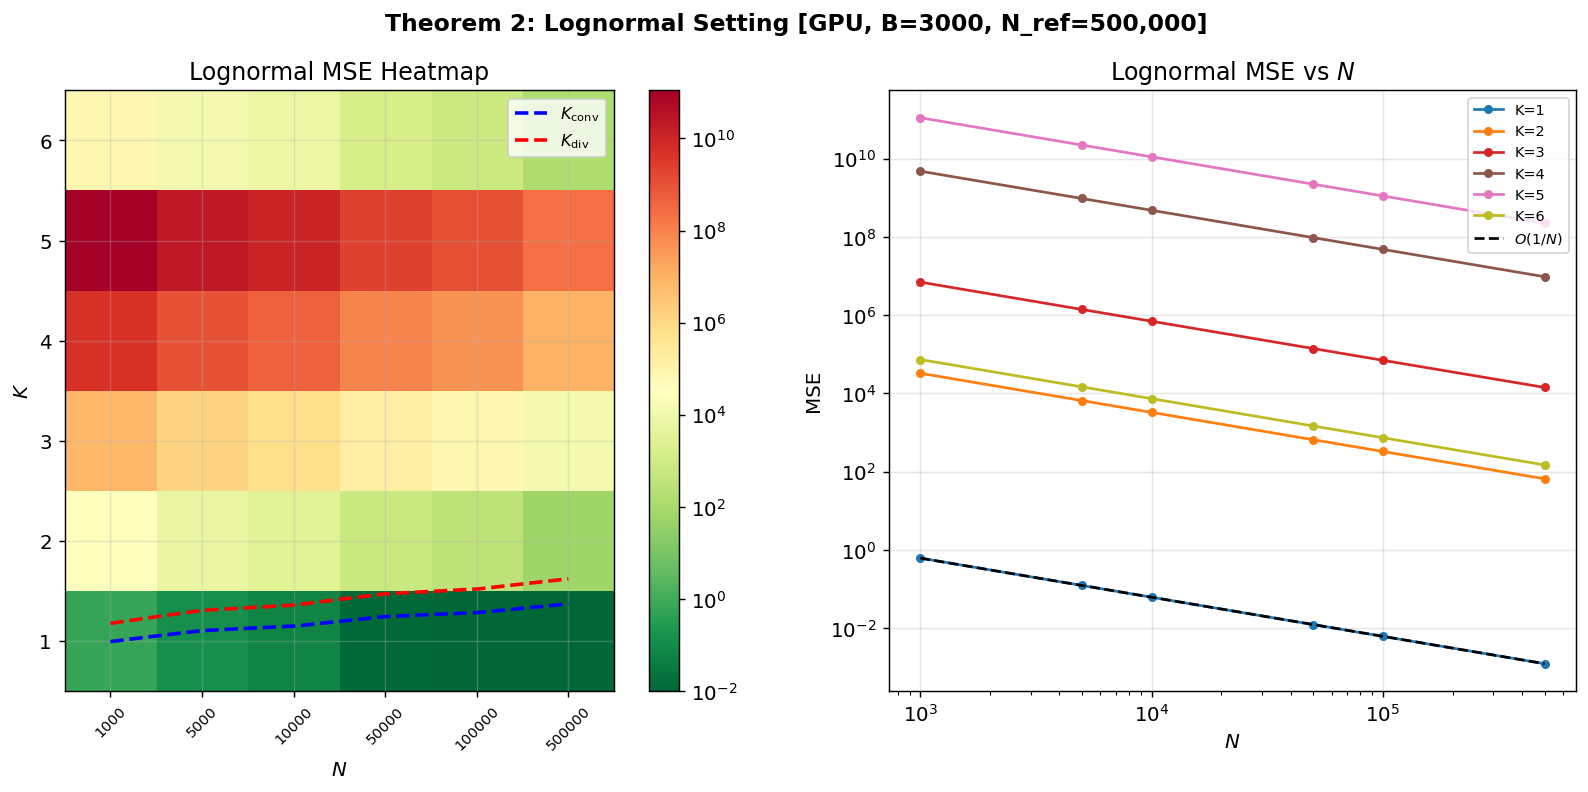

Saved: lognormal_results.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
t2c = np.clip(table2, 1e-4, None)
im2 = ax.imshow(t2c, aspect='auto', cmap='RdYlGn_r',
                norm=LogNorm(vmin=0.01, vmax=max(1e4, t2c.max())), origin='lower')
ax.set_xticks(range(len(N_vals_ln)))
ax.set_xticklabels([str(N) for N in N_vals_ln], rotation=45, fontsize=8)
ax.set_yticks(range(len(K_vals_ln)))
ax.set_yticklabels(K_vals_ln)
Nc_ln = np.linspace(0, len(N_vals_ln)-1, 200)
lNc_ln = np.interp(Nc_ln, range(len(N_vals_ln)), np.log(N_vals_ln))
ax.plot(Nc_ln, np.sqrt(lNc_ln/(5+2)) - K_vals_ln[0], 'b--', lw=2, label=r'$K_{\rm conv}$')
ax.plot(Nc_ln, np.sqrt(lNc_ln/(3+2)) - K_vals_ln[0], 'r--', lw=2, label=r'$K_{\rm div}$')
plt.colorbar(im2, ax=ax);  ax.legend(fontsize=9)
ax.set_xlabel('$N$');  ax.set_ylabel('$K$');  ax.set_title('Lognormal MSE Heatmap')

ax = axes[1]
N_ln_arr = np.array(N_vals_ln, dtype=float)
for ki, K in enumerate(K_vals_ln):
    ax.loglog(N_ln_arr, table2[ki], '-o', ms=4,
              color=plt.get_cmap('tab10')(ki/6), label=f'K={K}')
ax.loglog(N_ln_arr, table2[0,-1]*N_ln_arr[-1]/N_ln_arr, 'k--', lw=1.5, label=r'$O(1/N)$')
ax.set_xlabel('$N$');  ax.set_ylabel('MSE')
ax.set_title('Lognormal MSE vs $N$')
ax.legend(fontsize=8)

fig.suptitle(f'Theorem 2: Lognormal Setting [{DEVICE}, B=3000, N_ref={N_REF_LN:,}]',
             fontsize=13, fontweight='bold')
plt.savefig('lognormal_results.png', **SAVEFIG_KW);  plt.show()
print('Saved: lognormal_results.png')

## 2.5  Practical LSM: RMSE Grid in the $(N,K)$ Plane

Each trial is independent — we parallelise over trials using `joblib.Parallel`.

In [19]:
from joblib import Parallel, delayed

S0_put=40; K_put=40; r_put=0.06; sig_put=0.2; T_put=1.0; m_put=50
benchmark = binomial_american_put(S0_put, K_put, r_put, sig_put, T_put)
print(f'Benchmark: {benchmark:.4f}')

N_grid    = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
K_grid    = [2, 3, 4, 5, 6, 8, 10, 13]
N_TRIALS  = 20

def _lsm_trial(S0, Ks, r, sig, T, m, N, Kb, trial, ki, ni):
    p, _ = lsm_american_put(S0, Ks, r, sig, T, m, N, Kb,
                            seed=1000*trial + ni*100 + ki)
    return p

rmse_grid = np.zeros((len(K_grid), len(N_grid)))
bias_grid = np.zeros((len(K_grid), len(N_grid)))

t0_grid = time.perf_counter()
for ki, Kb in enumerate(K_grid):
    t0k = time.perf_counter()
    for ni, N in enumerate(N_grid):
        # Parallelise over N_TRIALS — each is embarrassingly independent
        prices = Parallel(n_jobs=-1, prefer='threads')(
            delayed(_lsm_trial)(S0_put, K_put, r_put, sig_put, T_put,
                                m_put, N, Kb, trial, ki, ni)
            for trial in range(N_TRIALS)
        )
        prices = np.array(prices)
        rmse_grid[ki, ni] = np.sqrt(np.mean((prices - benchmark)**2))
        bias_grid[ki, ni] = prices.mean() - benchmark
    print(f'  K={Kb:2d}: {time.perf_counter()-t0k:.1f}s')

print(f'\nLSM grid total: {time.perf_counter()-t0_grid:.1f}s  (parallel={N_TRIALS} trials/cell)')

Benchmark: 2.3195
  K= 2: 20.0s
  K= 3: 23.9s
  K= 4: 27.0s
  K= 5: 30.6s
  K= 6: 54.2s
  K= 8: 67.6s
  K=10: 83.7s
  K=13: 112.0s

LSM grid total: 419.2s  (parallel=20 trials/cell)


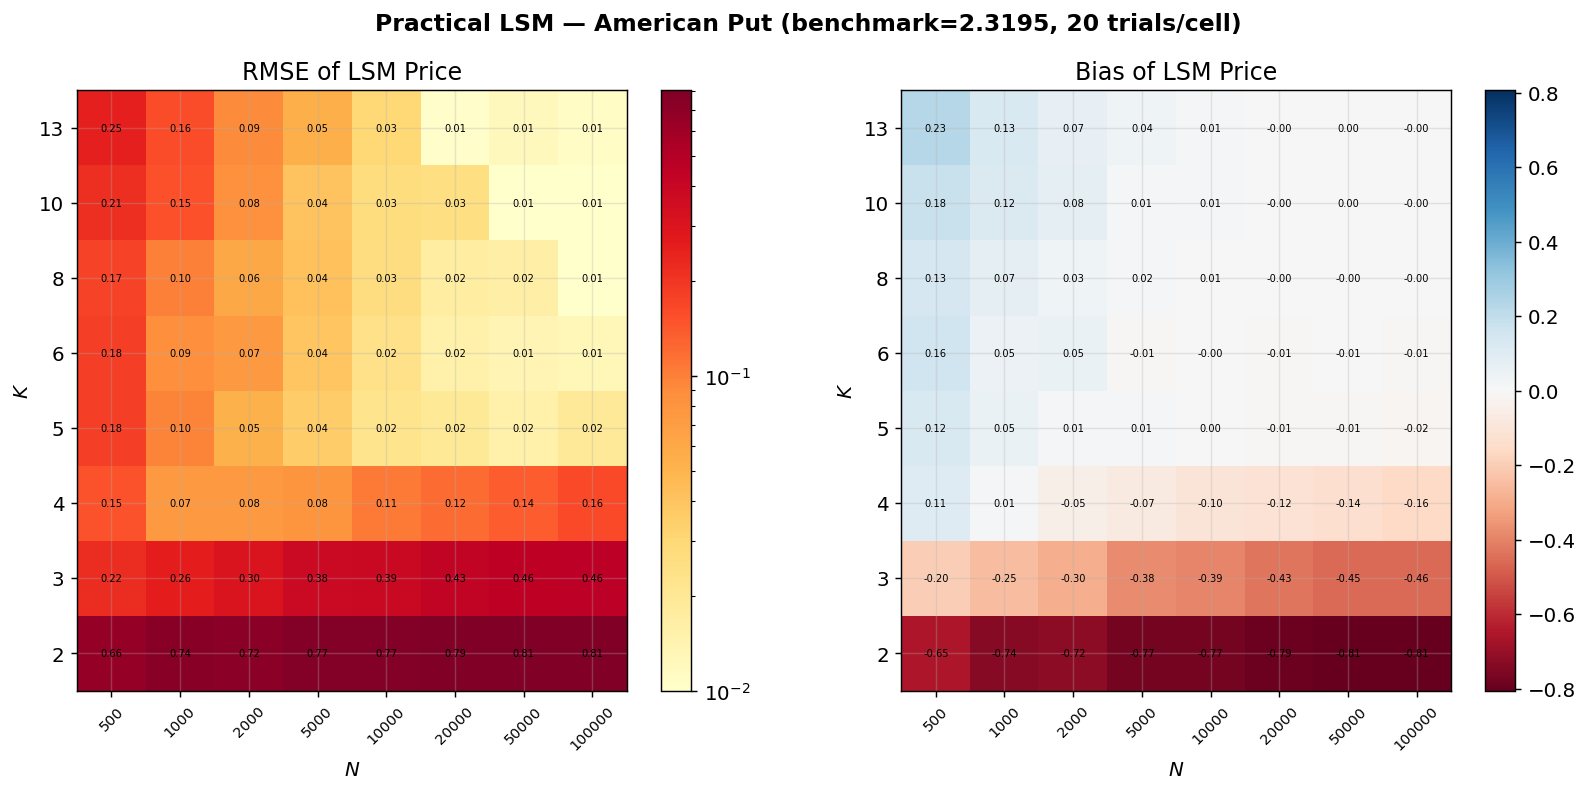

Saved: american_put_rmse.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, grid, title, cmap_n in zip(
    axes, [rmse_grid, bias_grid],
    ['RMSE of LSM Price', 'Bias of LSM Price'],
    ['YlOrRd', 'RdBu']
):
    if cmap_n == 'YlOrRd':
        norm = LogNorm(vmin=0.01, vmax=grid.max())
    else:
        bmax = max(abs(grid.min()), abs(grid.max()))
        norm = matplotlib.colors.TwoSlopeNorm(vmin=-bmax, vcenter=0, vmax=bmax)
    im = ax.imshow(grid, aspect='auto', cmap=cmap_n, norm=norm,
                   origin='lower', interpolation='nearest')
    ax.set_xticks(range(len(N_grid)))
    ax.set_xticklabels([str(N) for N in N_grid], rotation=45, fontsize=8)
    ax.set_yticks(range(len(K_grid)))
    ax.set_yticklabels(K_grid)
    ax.set_xlabel('$N$');  ax.set_ylabel('$K$');  ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for ki in range(len(K_grid)):
        for ni in range(len(N_grid)):
            ax.text(ni, ki, f'{grid[ki,ni]:.2f}', ha='center', va='center', fontsize=5.5)

fig.suptitle(f'Practical LSM — American Put (benchmark={benchmark:.4f}, {N_TRIALS} trials/cell)',
             fontsize=13, fontweight='bold')
plt.savefig('american_put_rmse.png', **SAVEFIG_KW);  plt.show()
print('Saved: american_put_rmse.png')

## 2.6  Comparison: K* Bounds + Overfitting Demo

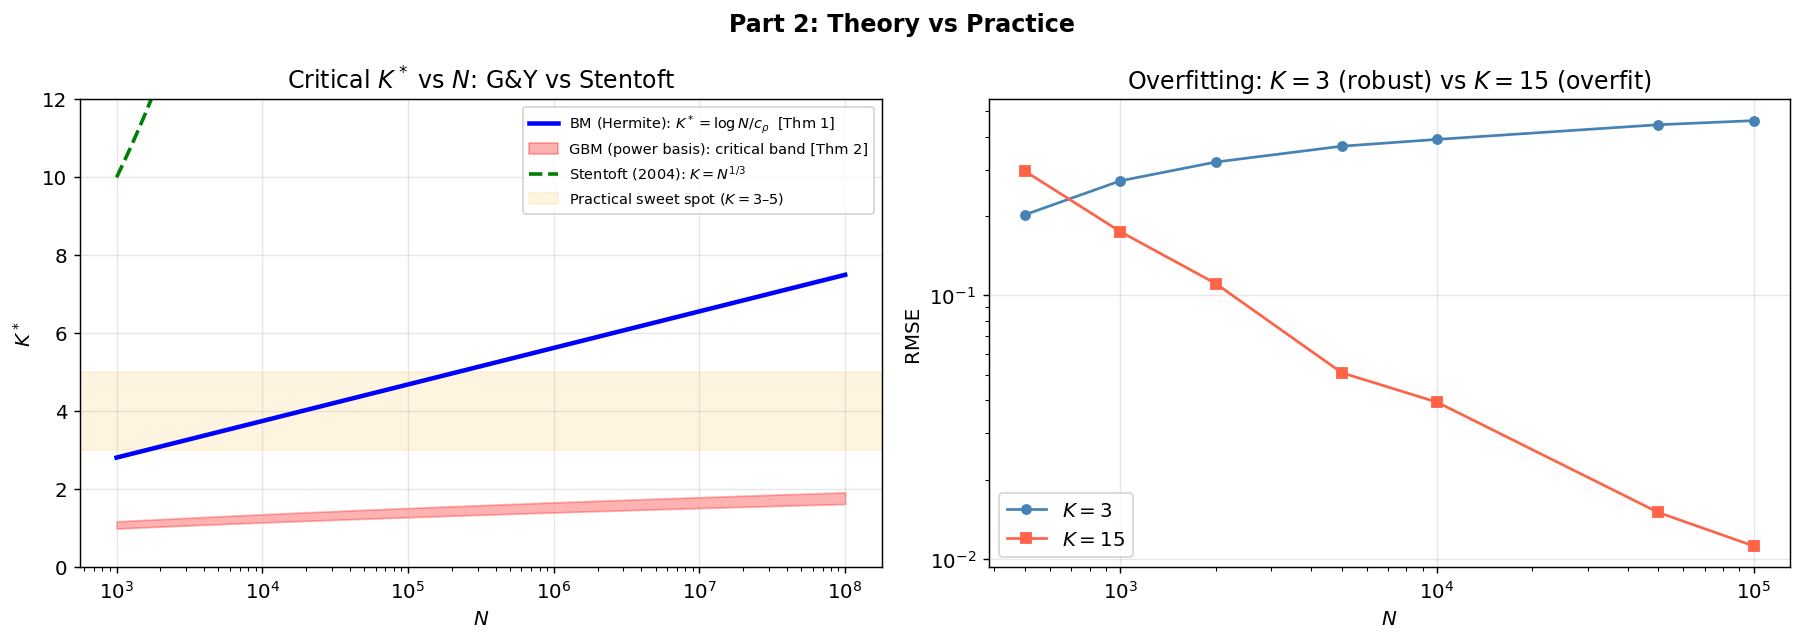

Saved: theory_vs_practice.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K* bounds comparison
ax = axes[0]
N_r = np.logspace(3, 8, 300)
ax.plot(N_r, np.log(N_r)/c_rho, 'b-', lw=2.5,
        label=r'BM (Hermite): $K^* = \log N/c_\rho$  [Thm 1]')
ax.fill_between(N_r, np.sqrt(np.log(N_r)/(3+2)), np.sqrt(np.log(N_r)/(5+2)),
                alpha=0.3, color='red', label='GBM (power basis): critical band [Thm 2]')
ax.plot(N_r, N_r**(1/3), 'g--', lw=2, label=r'Stentoft (2004): $K = N^{1/3}$')
ax.axhspan(3, 5, alpha=0.12, color='orange', label='Practical sweet spot ($K=3$–$5$)')
ax.set_xscale('log');  ax.set_ylim(0, 12)
ax.set_xlabel('$N$');  ax.set_ylabel('$K^*$')
ax.set_title('Critical $K^*$ vs $N$: G&Y vs Stentoft');  ax.legend(fontsize=8)

# Overfitting K=3 vs K=15
ax = axes[1]
N_ov = [500, 1000, 2000, 5000, 10000, 50000, 100000]
n_ov = 30

for Kb, col, mk in [(3, 'steelblue', 'o'), (15, 'tomato', 's')]:
    rmse_ov = []
    for N_o in N_ov:
        # 1. On lance Parallel sans le [0] à la fin
        results = Parallel(n_jobs=-1, prefer='threads')(
            delayed(lsm_american_put)(S0_put, K_put, r_put, sig_put, T_put,
                                     m_put, N_o, Kb, seed=t*137+1)
            for t in range(n_ov)
        )
        # 2. results est une liste de tuples (prix, se). On extrait les prix :
        prices = [res[0] for res in results]

        # 3. On calcule la RMSE sur ces prix extraits
        rmse_ov.append(np.sqrt(np.mean((np.array(prices) - benchmark)**2)))

    ax.loglog(N_ov, rmse_ov, f'{mk}-', color=col, ms=5, label=f'$K={Kb}$')

ax.set_xlabel('$N$');  ax.set_ylabel('RMSE')
ax.set_title('Overfitting: $K=3$ (robust) vs $K=15$ (overfit)');  ax.legend()

fig.suptitle('Part 2: Theory vs Practice', fontweight='bold')
plt.tight_layout()
plt.savefig('theory_vs_practice.png', dpi=150, bbox_inches='tight');  plt.show()
print('Saved: theory_vs_practice.png')

In [22]:
print('=' * 65)
print(f'NOTEBOOK COMPLETE  [{DEVICE}]')
print('=' * 65)
print('Figures saved:')
for f in ['greeks_all.png', 'weak_convergence.png', 'greek_histograms.png',
          'lemma_verification.png', 'MB_reproduction.png',
          'lognormal_results.png', 'american_put_rmse.png',
          'theory_vs_practice.png']:
    print(f'  {f}')
print()
print('Optimisations utilisees:')
print('  1. Shared-Z sweeps (Part 1): x10 sur les sweeps S0/sigma/B')
print('  2. One-pass-all-N MSE (Part 2): x9 sur le calcul de Table 1')
print('  3. float32 partout: x1.5-2 memoire et BLAS')
print('  4. joblib.Parallel sur les essais LSM: x4-8 CPU')
if DEVICE == 'GPU':
    print('  5. CuPy GPU: x10-50 sur toutes les operations matricielles')

NOTEBOOK COMPLETE  [GPU]
Figures saved:
  greeks_all.png
  weak_convergence.png
  greek_histograms.png
  lemma_verification.png
  MB_reproduction.png
  lognormal_results.png
  american_put_rmse.png
  theory_vs_practice.png

Optimisations utilisees:
  1. Shared-Z sweeps (Part 1): x10 sur les sweeps S0/sigma/B
  2. One-pass-all-N MSE (Part 2): x9 sur le calcul de Table 1
  3. float32 partout: x1.5-2 memoire et BLAS
  4. joblib.Parallel sur les essais LSM: x4-8 CPU
  5. CuPy GPU: x10-50 sur toutes les operations matricielles
